# Figure 3: Bound Summary

Translation of `Figure03_boundSummary.m`

## What this notebook does

Characterizes how participants' decision bounds vary with Decision Time (DT) and across trials in the online (OL) task.

Five panels (all using block 2, lowest SNR):

- **Panel A**: Individual trial bounds vs. DT for one example participant.
- **Panel B**: Z-scored bound vs. DT for all 60 participants (shows group-level DT dependence).
- **Panel C**: Histogram of linear-regression slopes (bound ~ DT) per participant.
- **Panel D**: Histogram of trial-to-trial bound change slopes (Δbound ~ current bound) per participant.
- **Panel E**: Mean ± SEM bound height vs. mean ± SEM DT per participant.

**Data**: Online (OL) task, block 2, lowest SNR condition.

## Imports

Imports standard scientific Python libraries plus `get_data_table` and `get_bound_summary` from the pigeon package. No data loading or filtering here.

## Load data

Loads all OL (open-loop) trials via `get_data_table(task_type='OL')`. Internal processing:
- Reads all CSV files from `DATA_DIR/Pigeon_OL/prolificcsvs/`
- Computes `bound`, `DT`, `RT` for each trial from step sequences
- Marks wall-hit trials (|position| ≥ 0.75) in the `wall_hit` column
- Applies bias correction if `boundBiasCorrection.mat` is present
- Combines blocks 4–6 into 1–3

All subjects and blocks retained at this stage.

## Compute bound summary

Calls `get_bound_summary(data_table_ol)` which applies the following filters internally (via `get_good_trial_array`):

**Data included**: Trials with `DT ≥ 1`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`, and `rt_below_cutoff = False` (RT meets the per-block/SNR reliability threshold from `get_bounds`).

**Data excluded**: Trials with `DT < 1` (too short), first 9 trials per block (warm-up), wall-hit trials, trials with missing bounds.

Output shape: `(n_subjects, n_blocks, n_snrs, n_rt_bins, 3)` where the last dimension is `[mean_abs_bound, std_abs_bound, n_trials]`.

## Select analysis parameters

Restricts analysis to block 2 (`BLOCK=2`) and the lowest SNR condition (`min_snr`). Constructs a boolean filter `lg` for all downstream panels.

**Data included**: Trials where `bound` is finite, `|SNR| ≈ min_snr` (using `np.isclose`), and `block_index == BLOCK`.

Note: the `get_bound_summary`-level filters (DT ≥ 1, trial_number ≥ 10, wall_hit=False) are already baked into `bound_summary`; the `lg` filter here is applied to the raw `data_table_ol` for panels that iterate over individual trials.

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.pathDefaults import FIGURES_DIR

In [2]:
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [3]:
# bound_summary shape: (n_subjects, n_blocks, n_snrs, n_rt_bins, 3)
# Last dim: [mean_abs_bound, std_abs_bound, n_trials]
bound_summary = get_bound_summary(data_table_ol)
print('bound_summary shape:', bound_summary.shape)

bound_summary shape: (60, 3, 2, 10, 3)


In [4]:
BLOCK = 2  # representative block (1-indexed)

n_subjects, n_blocks, n_snrs, n_rt_bins, _ = bound_summary.shape
dt_bins = np.arange(1, n_rt_bins + 1)

# Unique absolute SNR values present in the dataset
abs_snr = np.abs(data_table_ol['snr'].to_numpy())
snrs = np.sort(np.unique(abs_snr[np.isfinite(abs_snr)]))
min_snr = snrs[0]

# Matches MATLAB: Lg = isfinite(bound) & SNR==min(SNR) & blockIndex==BLOCK
lg = (
    data_table_ol['bound'].notna() &
    pd.Series(np.isclose(abs_snr, min_snr), index=data_table_ol.index) &
    (data_table_ol['block_index'] == BLOCK)
)

subjects = np.sort(data_table_ol['subject_index'].dropna().unique())

# Slice to block of interest; shape becomes (n_subjects, n_snrs, n_rt_bins)
bi = BLOCK - 1
bound_by_subj = bound_summary[:, bi, :, :, 0]

## Panel A: Example session
Individual trial bounds vs. DT for one example participant (block 2). Open symbols = individual trials; filled symbols = medians per DT.

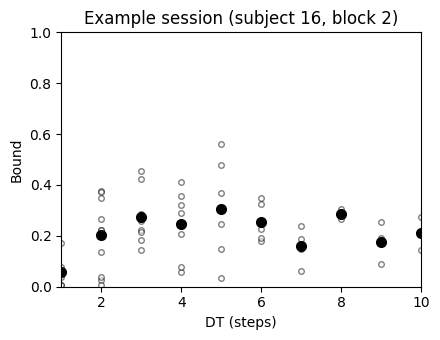

In [5]:
EXAMPLE_SESSION = 16  # subject index for example session

# Select valid trials for the example subject using the shared lg filter
ls_ex = lg & (data_table_ol['subject_index'] == EXAMPLE_SESSION)
ex = data_table_ol[ls_ex].copy()

# Compute mean |bound| and trial count at each DT bin
dt_vals = np.arange(1, n_rt_bins + 1)
mean_per_dt = [np.nanmean(np.abs(ex.loc[ex['DT'] == dt, 'bound'])) for dt in dt_vals]
n_per_dt    = [ex['DT'].eq(dt).sum() for dt in dt_vals]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Individual trials as open circles
ax.plot(ex['DT'], np.abs(ex['bound']), 'o', color='k',
        markerfacecolor='w', markersize=4, alpha=0.5)

# Mean per DT bin as filled circles (only where data exist)
mean_arr = np.array(mean_per_dt, dtype=float)
n_arr    = np.array(n_per_dt)
ax.plot(dt_vals[n_arr > 0], mean_arr[n_arr > 0], 'ko', markersize=7)

ax.set_xlabel('DT (steps)')
ax.set_ylabel('Bound')
ax.set_xlim(1, 10)
ax.set_ylim(0, 1)
ax.set_title(f'Example session (subject {EXAMPLE_SESSION}, block {BLOCK})')
plt.tight_layout()
plt.show()

## Panel B: Z-scored bound vs. DT — all 60 participants
Gray lines: per-participant median z-scored bound per DT. Black line: median of gray lines.

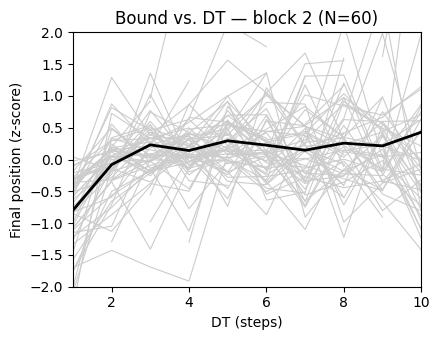

Group mean z-bound: Spearman r = 0.65, p = 0.0425


In [6]:
gr = (0.8, 0.8, 0.8)
dt_vals = np.arange(1, n_rt_bins + 1)

# One row per subject: mean z-scored |bound| at each DT bin
subj_means = np.full((len(subjects), n_rt_bins), np.nan)

for si, subj in enumerate(subjects):
    ls = lg & (data_table_ol['subject_index'] == subj)
    sub = data_table_ol[ls].copy()
    if len(sub) < 5:
        continue

    # Z-score |bound| within subject so participants are on a common scale
    ab = np.abs(sub['bound'].to_numpy(dtype=float))
    mu, sd = np.nanmean(ab), np.nanstd(ab)
    if sd == 0:
        continue
    sub['z_bound'] = (ab - mu) / sd

    for ri, dt in enumerate(dt_vals):
        vals = sub.loc[sub['DT'] == dt, 'z_bound']
        if len(vals) > 0:
            subj_means[si, ri] = np.nanmean(vals)

fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Individual subjects in gray, group mean in black
ax.plot(dt_vals, subj_means.T, '-', color=gr, linewidth=0.8)
group_mean = np.nanmean(subj_means, axis=0)
ax.plot(dt_vals, group_mean, 'k-', linewidth=2)

ax.set_xlabel('DT (steps)')
ax.set_ylabel('Final position (z-score)')
ax.set_title(f'Bound vs. DT — block {BLOCK} (N={len(subjects)})')
ax.set_xlim(1, 10)
ax.set_ylim(-2, 2)
plt.tight_layout()
plt.show()

# Test whether z-bound systematically varies with DT
valid = np.isfinite(group_mean)
if valid.sum() > 2:
    r, p = scipy.stats.spearmanr(dt_vals[valid], group_mean[valid])
    print(f'Group mean z-bound: Spearman r = {r:.2f}, p = {p:.4f}')

## Panel C: Histogram of linear-regression slopes (|bound| vs. DT)
Excludes DT≤2 to avoid unreliable short-DT estimates. Slope ~0 implies no systematic DT dependence.

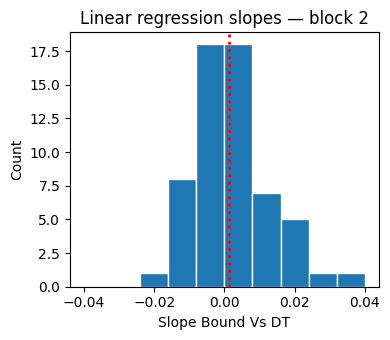

Slopes: median = 0.0013, Wilcoxon p = 0.3082


In [7]:
slopes_c = []

for subj in subjects:
    # Include DT >= 2 (matches MATLAB: Lgr = dataTable.DT >= 2)
    ls = lg & (data_table_ol['subject_index'] == subj) & (data_table_ol['DT'] >= 2)
    sub = data_table_ol[ls]
    if len(sub) < 5:
        continue
    dts = sub['DT'].to_numpy(dtype=float)
    ab  = np.abs(sub['bound'].to_numpy(dtype=float))
    finite = np.isfinite(dts) & np.isfinite(ab)
    if finite.sum() < 3:
        continue
    slope, intercept, r, p, se = scipy.stats.linregress(dts[finite], ab[finite])
    slopes_c.append(slope)

slopes_c = np.array(slopes_c)
med_c = np.nanmedian(slopes_c)

# Fixed bin edges matching MATLAB: hax{1} = -0.04:0.008:0.04
bins_c = np.arange(-0.04, 0.04 + 0.008, 0.008)

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.hist(slopes_c, bins=bins_c, edgecolor='w')
ax.axvline(med_c, color='r', linewidth=2, linestyle=':')  # median slope
ax.set_xlabel('Slope Bound Vs DT')
ax.set_ylabel('Count')
ax.set_title(f'Linear regression slopes — block {BLOCK}')
plt.tight_layout()
plt.show()

# Test whether slopes are significantly different from zero
_, p_sign = scipy.stats.wilcoxon(slopes_c)
print(f'Slopes: median = {med_c:.4f}, Wilcoxon p = {p_sign:.4f}')

## Panel D: Histogram of trial-to-trial bound slopes
For each participant: linear regression of change in |bound| (Δ|bound| = |bound|_t − |bound|_{t−1}) on current |bound| (|bound|_t). Matches MATLAB: `regress(deltaBounds(2:end), xs(2:end,:))` where `xs(:,2) = abounds(Ls)`.

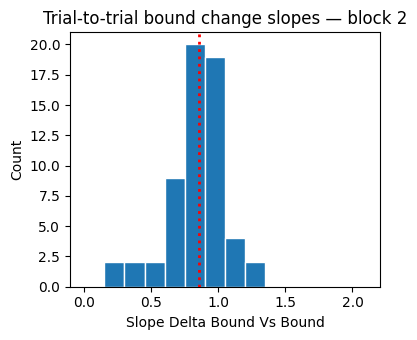

Slopes: median = 0.8589
Wilcoxon vs -1: p = 0.0000
Wilcoxon vs 0: p = 0.0000


In [8]:
slopes_d = []

for subj in subjects:
    ls = lg & (data_table_ol['subject_index'] == subj)
    # Sort by trial order to get consecutive pairs
    sub = data_table_ol[ls].sort_values('trial_number')
    if len(sub) < 5:
        continue
    ab = np.abs(sub['bound'].to_numpy(dtype=float))

    # Compute delta bound and regress onto CURRENT bound (matches MATLAB:
    # regress(deltaBounds(2:end), xs(2:end,:)) where xs(:,2) = abounds(Ls))
    prev  = ab[:-1]
    curr  = ab[1:]
    delta = curr - prev
    finite = np.isfinite(curr) & np.isfinite(delta)
    if finite.sum() < 3:
        continue
    slope, intercept, r, p, se = scipy.stats.linregress(curr[finite], delta[finite])
    slopes_d.append(slope)

slopes_d = np.array(slopes_d)
med_d = np.nanmedian(slopes_d)

# Fixed bin edges matching MATLAB: hax{2} = 0:0.15:2
bins_d = np.arange(0, 2 + 0.15, 0.15)

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.hist(slopes_d, bins=bins_d, edgecolor='w')
ax.axvline(med_d, color='r', linewidth=2, linestyle=':')  # median slope
ax.set_xlabel('Slope Delta Bound Vs Bound')
ax.set_ylabel('Count')
ax.set_title(f'Trial-to-trial bound change slopes — block {BLOCK}')
plt.tight_layout()
plt.show()

# Test vs. −1 (regression to mean) and vs. 0 (no change)
_, p_sign = scipy.stats.wilcoxon(slopes_d + 1)
print(f'Slopes: median = {med_d:.4f}')
print(f'Wilcoxon vs -1: p = {p_sign:.4f}')
_, p_zero = scipy.stats.wilcoxon(slopes_d)
print(f'Wilcoxon vs 0: p = {p_zero:.4f}')

## Panel E: Mean±sem bound height vs. mean±sem DT
One data point per participant (block 2). Error bars are SEM across trials.

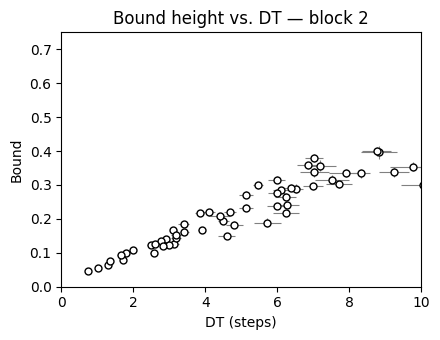

Mean bound vs mean DT: Spearman r = 0.96, p = 0.0000


In [9]:
# Per-subject mean and SEM of |bound| and DT
mean_bound = np.full(len(subjects), np.nan)
sem_bound  = np.full(len(subjects), np.nan)
mean_dt    = np.full(len(subjects), np.nan)
sem_dt     = np.full(len(subjects), np.nan)

for si, subj in enumerate(subjects):
    ls = lg & (data_table_ol['subject_index'] == subj)
    sub = data_table_ol[ls]
    if len(sub) < 5:
        continue
    ab  = np.abs(sub['bound'].to_numpy(dtype=float))
    dts = sub['DT'].to_numpy(dtype=float)
    n = len(sub)
    mean_bound[si] = np.nanmean(ab)
    sem_bound[si]  = np.nanstd(ab) / np.sqrt(n)
    mean_dt[si]    = np.nanmean(dts)
    sem_dt[si]     = np.nanstd(dts) / np.sqrt(n)

valid = np.isfinite(mean_bound) & np.isfinite(mean_dt)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.errorbar(
    mean_dt[valid], mean_bound[valid],
    xerr=0.5 * sem_dt[valid], yerr=0.5 * sem_bound[valid],  # matches MATLAB: 0.5*SEM
    fmt='ko', markerfacecolor='w', markersize=5,
    ecolor='gray', elinewidth=0.8, capsize=0
)
ax.set_xlabel('DT (steps)')
ax.set_ylabel('Bound')
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.75)
ax.set_title(f'Bound height vs. DT — block {BLOCK}')
plt.tight_layout()
plt.show()

r, p = scipy.stats.spearmanr(mean_dt[valid], mean_bound[valid])
print(f'Mean bound vs mean DT: Spearman r = {r:.2f}, p = {p:.4f}')

## Formatted figure

Reproduces the 5-panel figure at publication dimensions matching MATLAB's `getPLOT_axes` call:

```matlab
getPLOT_axes(3, 8.5, [4,4,2,4], {1,1,2,1}, 1.3, 1.5, [], 'Pigeons', true)
```

- **Width**: 8.5 cm (1 JNeurosci column)
- **Row heights**: [4, 4, 2, 4] cm; vertical separation 1.3 cm; horizontal 1.5 cm
- **Font size**: 12 pt
- Panels A, B, E span the full width; panels C and D share row 3 as equal halves (matching `cols={1,1,2,1}`).
- Saves to `Figure03_formatted.pdf`.

In [ ]:
# ── Publication layout matching MATLAB getPLOT_axes(3, 8.5, [4,4,2,4], {1,1,2,1}, 1.3, 1.5) ──
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 8.5
HTS = [4.0, 4.0, 2.0, 4.0]
PSH = 1.3
PSW = 1.5
FS  = 12

fig_h       = sum(HTS) + PSH * (len(HTS) - 1)   # 17.9 cm
panel_w     = (WID - PSW) / 2                    # 3.5 cm
hspace_frac = PSH / np.mean(HTS)                 # 1.3 / 3.5
wspace_frac = PSW / panel_w                      # 1.5 / 3.5

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(4, 2, figure=fig_fmt,
                       height_ratios=HTS,
                       hspace=hspace_frac, wspace=wspace_frac,
                       left=0, right=1, bottom=0, top=1)

# Panels A, B, E span both columns (matching cols={1,1,2,1});
# Panels C and D share row 2 as equal halves
ax_A = fig_fmt.add_subplot(gs[0, :])
ax_B = fig_fmt.add_subplot(gs[1, :])
ax_C = fig_fmt.add_subplot(gs[2, 0])
ax_D = fig_fmt.add_subplot(gs[2, 1])
ax_E = fig_fmt.add_subplot(gs[3, :])

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

gr_fmt   = (0.8, 0.8, 0.8)
dt_vals_fmt = np.arange(1, n_rt_bins + 1)

# ── Panel A: Example session — individual bounds vs. DT ───────────────────────
ls_ex = lg & (data_table_ol['subject_index'] == EXAMPLE_SESSION)
ex = data_table_ol[ls_ex].copy()
mean_per_dt_fmt = [np.nanmean(np.abs(ex.loc[ex['DT'] == dt, 'bound']))
                   for dt in dt_vals_fmt]
n_per_dt_fmt    = [ex['DT'].eq(dt).sum() for dt in dt_vals_fmt]
mean_arr_fmt = np.array(mean_per_dt_fmt, dtype=float)
n_arr_fmt    = np.array(n_per_dt_fmt)

ax_A.plot(ex['DT'], np.abs(ex['bound']), 'o', color='k',
          markerfacecolor='w', markersize=4, alpha=0.5)
ax_A.plot(dt_vals_fmt[n_arr_fmt > 0], mean_arr_fmt[n_arr_fmt > 0],
          'ro', markerfacecolor='r', markersize=7)
ax_A.set_xlim(1, 10)
ax_A.set_ylim(0, 1)
ax_A.set_ylabel('Bound')

# ── Panel B: Z-scored bound vs. DT — all subjects ─────────────────────────────
ax_B.plot(dt_vals_fmt, subj_means.T, '-', color=gr_fmt, linewidth=0.8)
ax_B.plot(dt_vals_fmt, np.nanmean(subj_means, axis=0), 'r-', linewidth=2)
ax_B.set_xlim(1, 10)
ax_B.set_ylim(-2, 2)
ax_B.set_xlabel('DT (steps)')
ax_B.set_ylabel('Final position (z-score)')

# ── Panel C: Histogram of bound-vs-DT regression slopes ──────────────────────
ax_C.hist(slopes_c, bins=bins_c, edgecolor='w')
ax_C.axvline(med_c, color='r', linewidth=2, linestyle=':')
ax_C.set_xlabel('Slope Bound Vs DT')
ax_C.set_ylabel('Count')

# ── Panel D: Histogram of delta-bound-vs-bound slopes ────────────────────────
ax_D.hist(slopes_d, bins=bins_d, edgecolor='w')
ax_D.axvline(med_d, color='r', linewidth=2, linestyle=':')
ax_D.set_xlabel('Slope Delta Bound Vs Bound')

# ── Panel E: Mean±SEM bound vs. mean±SEM DT — per subject ────────────────────
ax_E.errorbar(
    mean_dt[valid], mean_bound[valid],
    xerr=0.5 * sem_dt[valid], yerr=0.5 * sem_bound[valid],
    fmt='ko', markerfacecolor='w', markersize=5,
    ecolor='gray', elinewidth=0.8, capsize=0)
ax_E.set_xlim(0, 10)
ax_E.set_ylim(0, 0.75)
ax_E.set_xlabel('DT (steps)')
ax_E.set_ylabel('Bound')

for ax in [ax_A, ax_B, ax_C, ax_D, ax_E]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure03_formatted.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')